# 09 - Theme conviction: mentions x sentiment combined, per THEME

The SAME conviction analysis as notebook 08, but rolled up to the
TRADEABLE theme buckets from `src/themes.py` (each anchored to an ETF in
`THEME_ETFS`). Themes aggregate hundreds of posts a day, so every line
here is much more stable than a single ticker's - the theme version is
the one that maps directly onto an instrument you can actually buy.

Same four combinations, weakest to strongest:

1. **Bull pressure** = bullish posts minus bearish posts per day
   (= `n_posts x net_bullish`). One number carrying volume AND direction.
2. **Conviction z** = 7-day rolling bull pressure, z-scored against the
   theme's OWN window history. +2 = the crowd in this theme is unusually
   large AND unusually bullish - comparable across big and small themes.
3. **Divergence flags** - attention surging while sentiment DETERIORATES
   is the crowded-top / panic pattern; attention surging while sentiment
   improves is a confirmed swarm.
4. **Weekly heatmaps + snail trails** - the theme momentum map (notebook
   07) is a 5-day snapshot; the heatmap unrolls it over every week of
   the window, and the snail trail traces one theme's monthly PATH
   through the attention-vs-sentiment plane.

Needs `daily_theme_sentiment.parquet` from notebook 07 (self-contained
otherwise). Saves `daily_theme_conviction.parquet` - the theme-level
composite signal for the trading signals (notebook 10) and the price
backtest (notebook 11).

In [1]:
import os, sys
ROOT = os.path.dirname(os.getcwd()) if os.path.basename(os.getcwd()) == 'notebooks' else os.getcwd()
sys.path.insert(0, ROOT)
print('project root:', ROOT)

project root: C:\Users\alexd\Desktop\GIC\RetailFlow1


In [2]:
# ============ PARAMETERS - edit these ============
SENT_PATH       = os.path.join(ROOT, 'data', 'processed', 'daily_theme_sentiment.parquet')
CONVICTION_OUT  = os.path.join(ROOT, 'data', 'processed', 'daily_theme_conviction.parquet')
THEMES          = []    # e.g. ['semiconductors', 'crypto']; [] = TOP_N by post volume
TOP_N           = 6
ROLL            = 7     # rolling window for bull pressure
HEATMAP_THEMES  = 20    # rows in the weekly heatmaps
TRAIL_THEMES    = 4     # snail trails to draw (one figure each)
DIVERGENCE_Z    = 1.0   # attention z above this counts as 'surging'
# ==================================================

In [3]:
# Build bull pressure + conviction z per theme per day.
import numpy as np
import pandas as pd
import importlib
import src.themes
importlib.reload(src.themes)
from src.themes import THEME_ETFS

if not os.path.exists(SENT_PATH):
    raise FileNotFoundError('daily_theme_sentiment.parquet not found - run notebook 07 first.')
sent = pd.read_parquet(SENT_PATH)
sent['date'] = pd.to_datetime(sent['date'])
WINDOW = f"{sent['date'].min().date()} to {sent['date'].max().date()}"
print('window:', WINDOW, '|', sent['theme'].nunique(), 'themes')

def lab(theme):
    return f"{theme} ({THEME_ETFS.get(theme, '?')})"

# bull pressure: net bullish POST COUNT (volume x direction in one number)
sent['bull_pressure'] = sent['n_posts'] * sent['net_bullish']

all_days = pd.date_range(sent['date'].min(), sent['date'].max(), freq='D')
wide_bp = (sent.pivot_table(index='date', columns='theme', values='bull_pressure')
           .reindex(all_days).fillna(0))          # no posts = zero pressure
wide_n  = (sent.pivot_table(index='date', columns='theme', values='n_posts')
           .reindex(all_days).fillna(0))

roll_bp = wide_bp.rolling(ROLL, min_periods=1).sum()
roll_n  = wide_n.rolling(ROLL, min_periods=1).sum()

# conviction z: each theme vs its OWN window mean/std of rolled pressure
conviction_z = (roll_bp - roll_bp.mean()) / roll_bp.std().replace(0, np.nan)
# attention z: same idea on volume only (used for the divergence flags)
attention_z = (roll_n - roll_n.mean()) / roll_n.std().replace(0, np.nan)

out = (conviction_z.stack().rename('conviction_z').reset_index()
       .rename(columns={'level_0': 'date'}))
out.to_parquet(CONVICTION_OUT, index=False)
print('saved ->', CONVICTION_OUT)

if THEMES:
    chosen = THEMES
else:
    chosen = list(wide_n.sum().sort_values(ascending=False).head(TOP_N).index)
print('analysing:', [lab(t) for t in chosen])

window: 2021-01-01 to 2021-12-31 | 39 themes
saved -> C:\Users\alexd\Desktop\GIC\RetailFlow1\data\processed\daily_theme_conviction.parquet
analysing: ['crypto (IBIT)', 'meme_stocks (GME)', 'short_squeeze (GME)', 'financials (XLF)', 'ai_megacap (MAGS)', 'consumer_retail (XLY)']


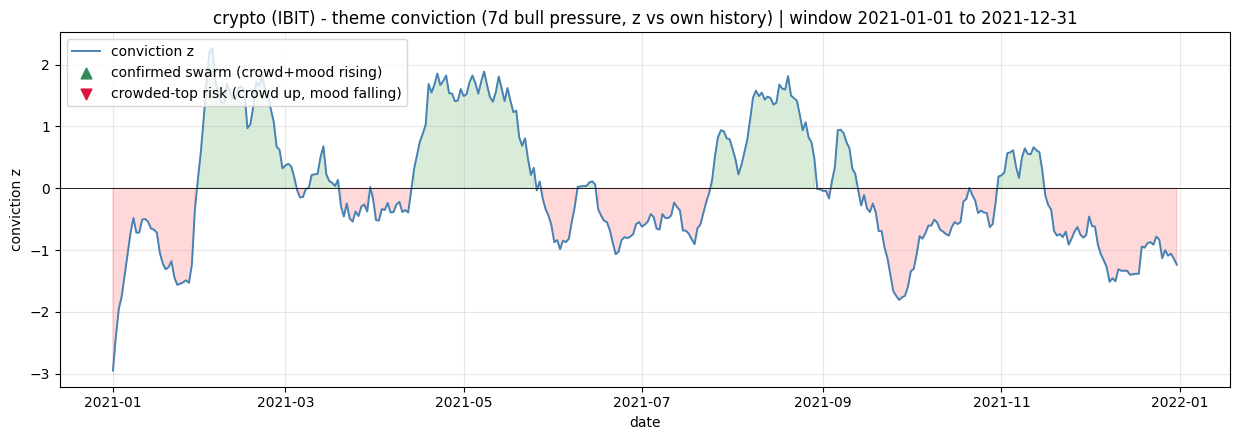

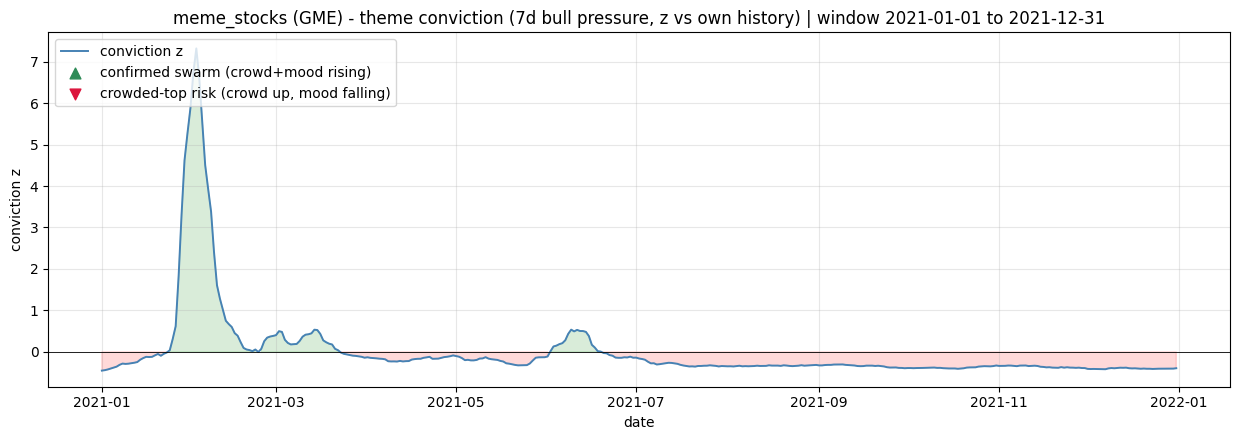

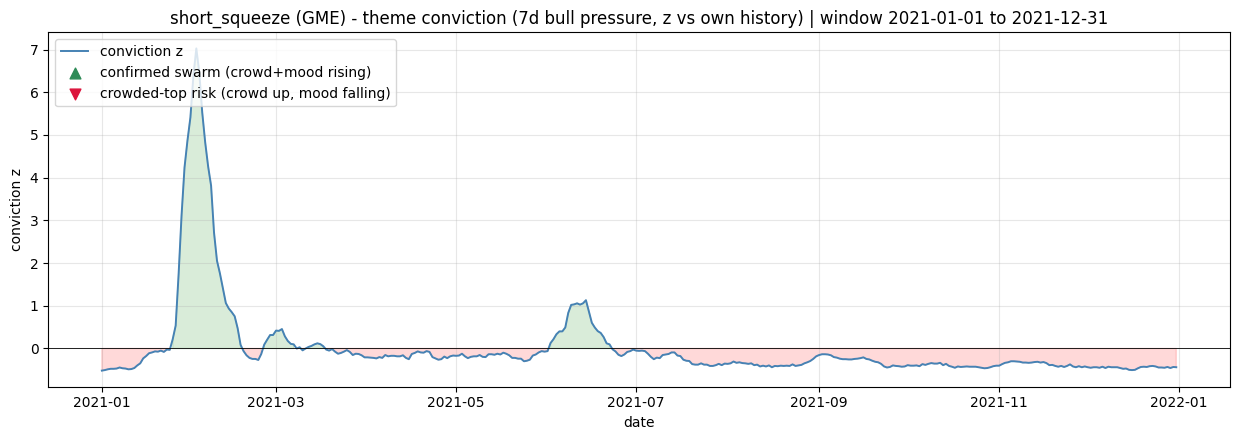

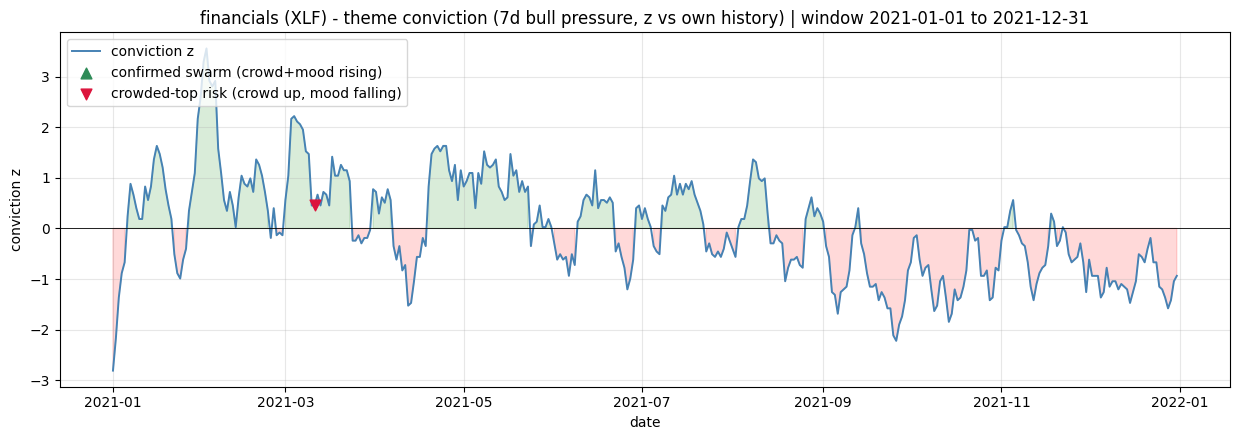

financials CROWDED-TOP: 2021-03-11


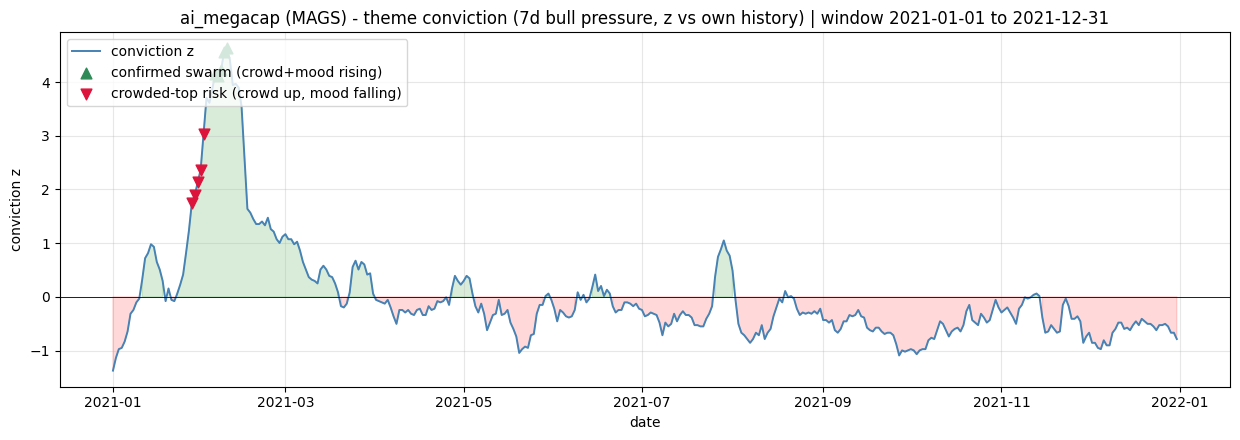

ai_megacap SWARM: 2021-02-05, 2021-02-06, 2021-02-07, 2021-02-08, 2021-02-09
ai_megacap CROWDED-TOP: 2021-01-28, 2021-01-29, 2021-01-30, 2021-01-31, 2021-02-01


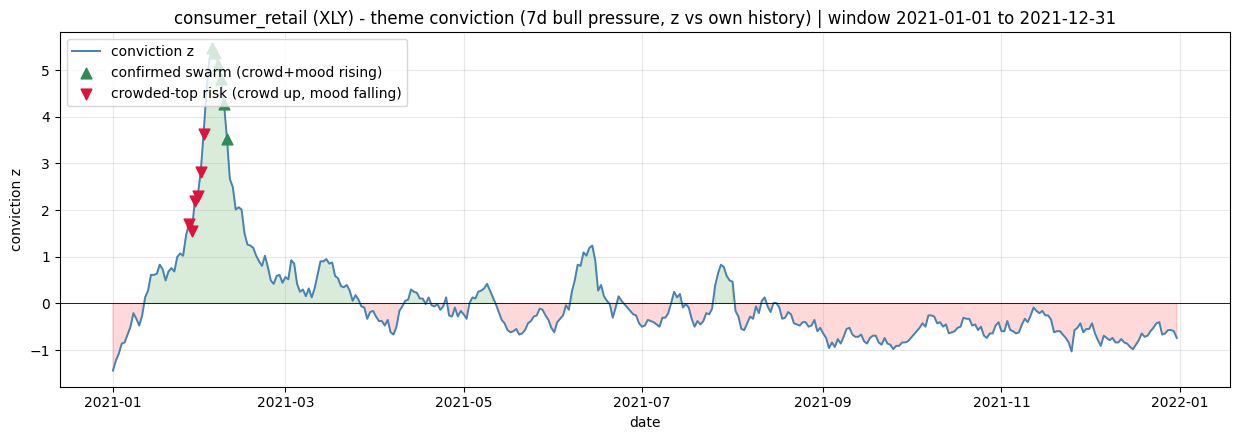

consumer_retail SWARM: 2021-02-04, 2021-02-05, 2021-02-06, 2021-02-07, 2021-02-08, 2021-02-09
consumer_retail CROWDED-TOP: 2021-01-27, 2021-01-28, 2021-01-29, 2021-01-30, 2021-01-31, 2021-02-01


In [4]:
# CONVICTION CHART per theme + divergence flags.
import matplotlib.pyplot as plt

# sentiment CHANGE: 5-day difference of the rolling bullish share
share = (roll_bp / roll_n.replace(0, np.nan))     # rolled net_bullish share
sent_change = share.diff(5)

for theme in chosen:
    cz = conviction_z[theme]
    az = attention_z[theme]
    dv = sent_change[theme]

    crowded_top = (az > DIVERGENCE_Z) & (dv < -0.10)   # crowd up, mood down
    swarm       = (az > DIVERGENCE_Z) & (dv > +0.10)   # crowd up, mood up

    fig, ax = plt.subplots(figsize=(12.5, 4.5))
    ax.plot(cz.index, cz, linewidth=1.4, color='steelblue', label='conviction z')
    ax.fill_between(cz.index, 0, cz, where=cz >= 0, alpha=0.15, color='green')
    ax.fill_between(cz.index, 0, cz, where=cz < 0, alpha=0.15, color='red')
    ax.scatter(cz.index[swarm], cz[swarm], marker='^', s=60, color='seagreen',
               zorder=5, label='confirmed swarm (crowd+mood rising)')
    ax.scatter(cz.index[crowded_top], cz[crowded_top], marker='v', s=60,
               color='crimson', zorder=5, label='crowded-top risk (crowd up, mood falling)')
    ax.axhline(0, color='black', linewidth=0.6)
    ax.set_title(f'{lab(theme)} - theme conviction ({ROLL}d bull pressure, z vs own history) | window {WINDOW}')
    ax.set_ylabel('conviction z'); ax.set_xlabel('date')
    ax.legend(loc='upper left'); ax.grid(True, alpha=0.3)
    plt.tight_layout(); plt.show()

    for label, mask in (('SWARM', swarm), ('CROWDED-TOP', crowded_top)):
        days = list(cz.index[mask].strftime('%Y-%m-%d'))
        if days:
            print(f'{theme} {label}: {", ".join(days[:8])}' + (' ...' if len(days) > 8 else ''))

## Weekly heatmaps - the theme momentum map unrolled over time

Notebook 07's momentum map shows ONE 5-day snapshot. These heatmaps show
every week of the window at once: rows = the most-posted themes (with
their anchor ETFs), columns = weeks, colour = the value that week (grey
= too few posts to score).

- **Heatmap 1: sentiment** (weekly net bullish share, red -1 .. green +1).
  Read rows for a theme's mood over time, columns for market-wide shifts.
- **Heatmap 2: conviction z** - where volume AND direction were unusual
  together. A bright green cell = that theme's crowd was unusually big
  and bullish that week; deep red = unusually big and bearish.

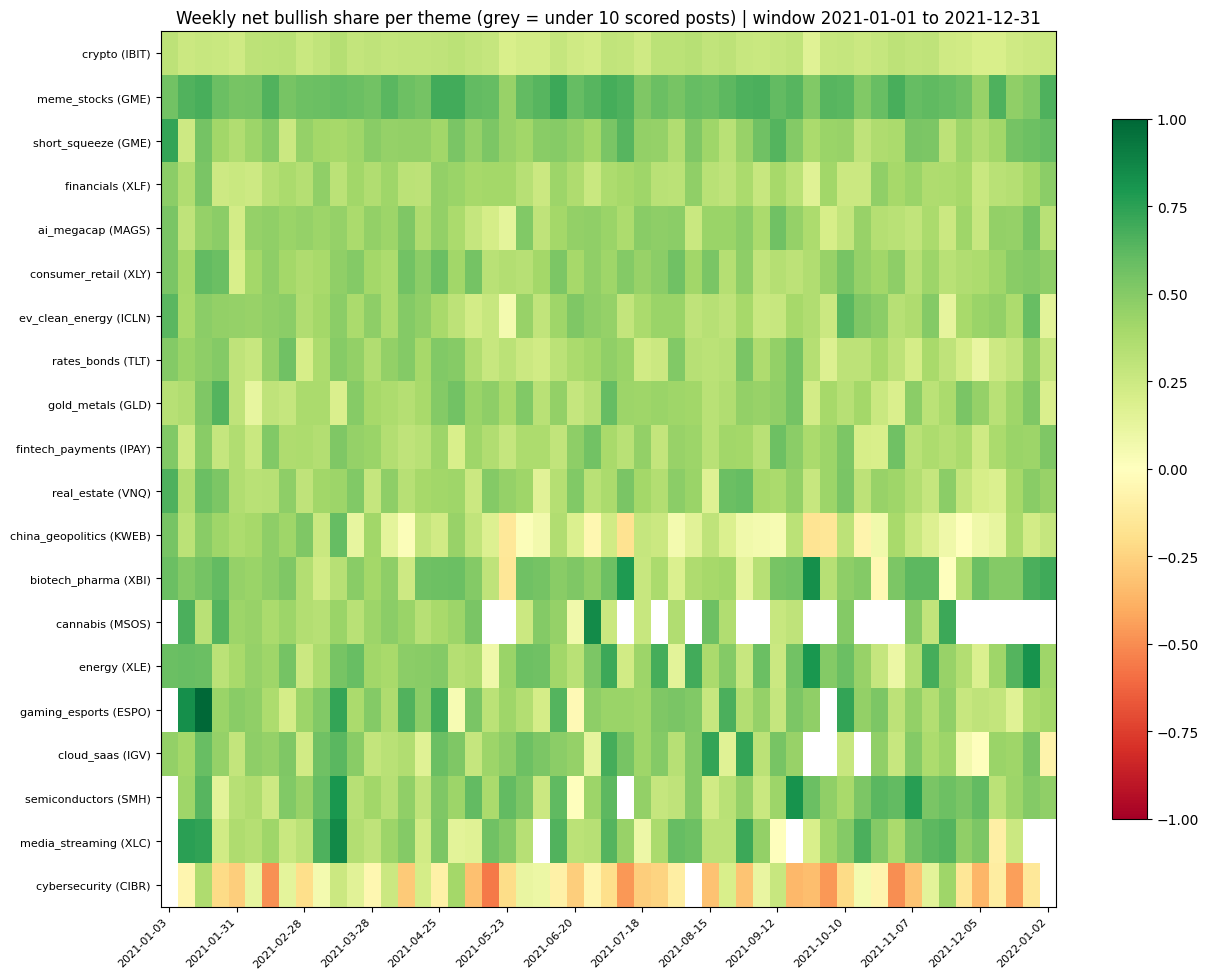

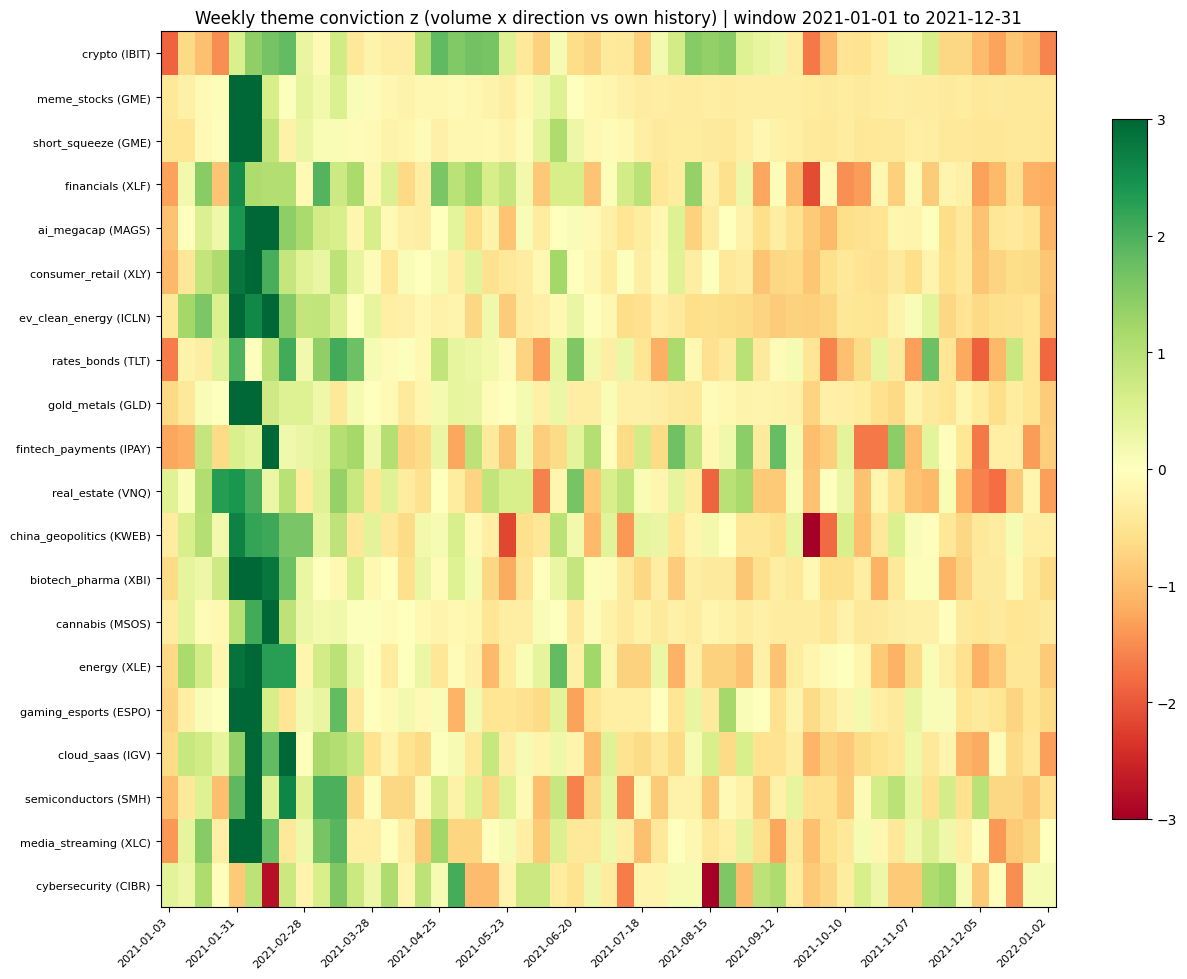

In [5]:
top = list(wide_n.sum().sort_values(ascending=False).head(HEATMAP_THEMES).index)

wk_bp = wide_bp[top].resample('W').sum()
wk_n  = wide_n[top].resample('W').sum()
wk_share = (wk_bp / wk_n.replace(0, np.nan)).where(wk_n >= 10)   # grey out thin weeks
wk_cz = ((wk_bp - wk_bp.mean()) / wk_bp.std().replace(0, np.nan))

def heatmap(frame, title, vmin, vmax):
    fig, ax = plt.subplots(figsize=(13, 0.42 * len(top) + 1.5))
    data = frame.T  # rows = themes, columns = weeks
    im = ax.imshow(data, aspect='auto', cmap='RdYlGn', vmin=vmin, vmax=vmax)
    ax.set_yticks(range(len(data.index)), [lab(t) for t in data.index], fontsize=8)
    ticks = range(0, len(data.columns), max(1, len(data.columns) // 12))
    ax.set_xticks(list(ticks), [data.columns[i].strftime('%Y-%m-%d') for i in ticks],
                  rotation=45, ha='right', fontsize=8)
    ax.set_title(f'{title} | window {WINDOW}')
    fig.colorbar(im, ax=ax, shrink=0.8)
    plt.tight_layout(); plt.show()

heatmap(wk_share, 'Weekly net bullish share per theme (grey = under 10 scored posts)', -1, 1)
heatmap(wk_cz, 'Weekly theme conviction z (volume x direction vs own history)', -3, 3)

## Snail trails - a theme's path through the plane

One dot per month: x = average attention z, y = average net bullish share
that month, connected in time order (darker = more recent, the label is
the month). A healthy swarm walks right AND up; the classic blow-off
pattern walks right while sliding DOWN (crowd still growing, mood already
rolling over). Theme trails are smoother than single-ticker ones - watch
them against the anchor ETF's chart.

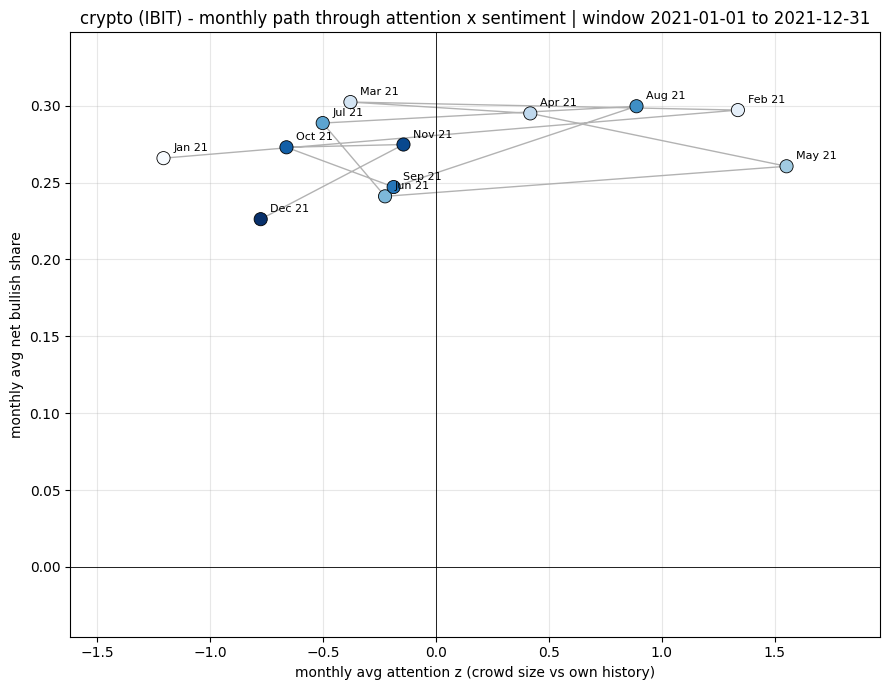

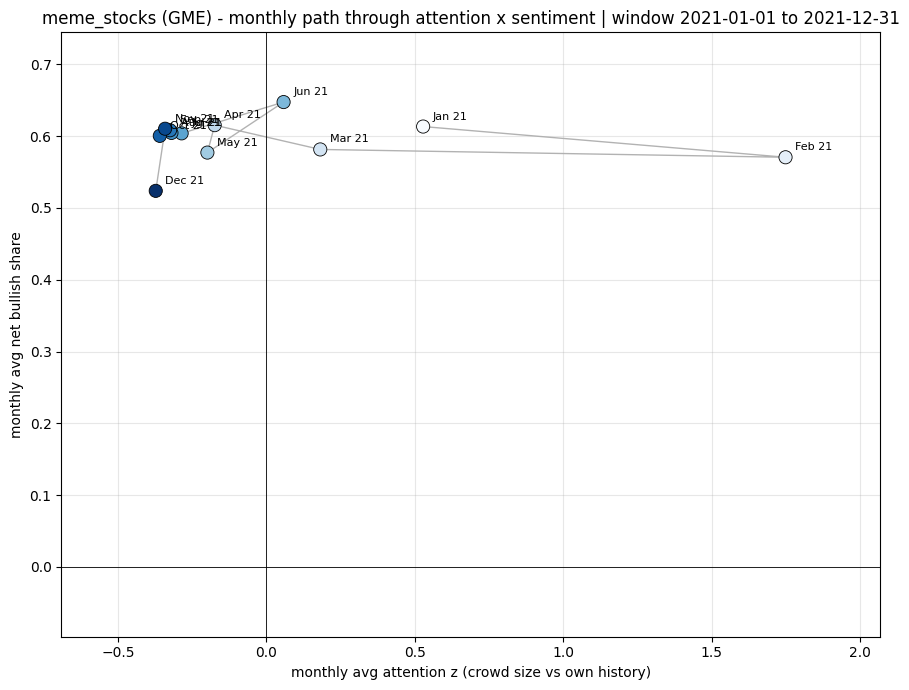

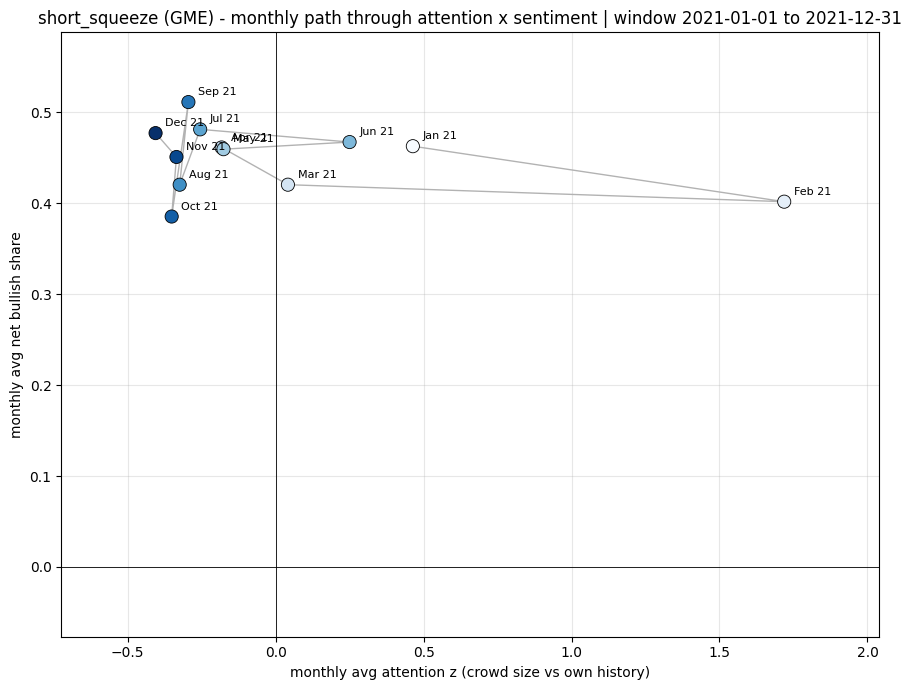

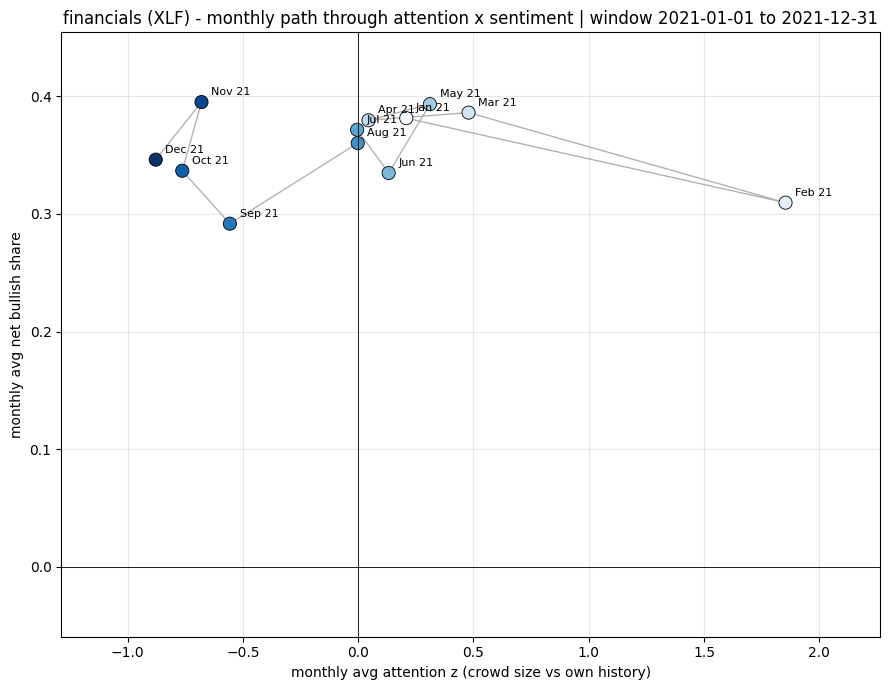

In [6]:
for theme in chosen[:TRAIL_THEMES]:
    ax_m = attention_z[theme].resample('ME').mean()
    share_m = share[theme].resample('ME').mean()
    trail = pd.DataFrame({'az': ax_m, 'share': share_m}).dropna()
    if len(trail) < 3:
        print('skip', theme, '- fewer than 3 months of data'); continue

    fig, ax = plt.subplots(figsize=(9, 7))
    shades = np.linspace(0.25, 1.0, len(trail))
    ax.plot(trail['az'], trail['share'], color='gray', linewidth=1, alpha=0.6, zorder=1)
    ax.scatter(trail['az'], trail['share'], s=90, c=shades, cmap='Blues',
               edgecolors='black', linewidths=0.6, zorder=2)
    for i, (idx, r) in enumerate(trail.iterrows()):
        ax.annotate(idx.strftime('%b %y'), (r['az'], r['share']),
                    textcoords='offset points', xytext=(7, 5), fontsize=8)
    ax.axhline(0, color='black', linewidth=0.6)
    ax.axvline(0, color='black', linewidth=0.6)
    ax.margins(0.15)
    ax.set_xlabel('monthly avg attention z (crowd size vs own history)')
    ax.set_ylabel('monthly avg net bullish share')
    ax.set_title(f'{lab(theme)} - monthly path through attention x sentiment | window {WINDOW}')
    ax.grid(True, alpha=0.3)
    plt.tight_layout(); plt.show()

## Caveats & what to do with this

- Same inheritance as notebook 08: sampling noise from the scored-post
  cap and lexicon bias from VADER. The z-scoring removes the constant
  bullish LEVEL bias per theme, but a market-wide mood swing still moves
  every theme at once (that is real information, not a bug).
- A ticker can belong to SEVERAL themes, so themes are NOT independent:
  a single NVDA swarm lifts `semiconductors`, `ai` and `ai_megacap`
  together. Correlated rows in the heatmap are often one crowd, not three.
- Divergence flags are descriptive, not signals, until they survive the
  price backtest: notebook 11 should test theme conviction_z against the
  anchor ETFs the same way WEEK2.md tests raw mentions.
- Everything here uses SCORED posts; with sampling on (notebooks 06/07),
  absolute volumes are proportional estimates.